## 002 - AppleCider Photometry
<a id='index'></a> <br>

- [part 1: import stuff, other basic things](#import)
    - if you haven't already processed the dataset into alerts, go back to [001: data pre-processing walkthrough](https://github.com/ajunell/AppleCider/blob/main/notebooks/001-data-processing.ipynb). you can skip to the `TransientDataset` part if you use `data_train.csv`, `data_test.csv`.
- [part 2: Dataset](#dataset)
- [part 3: DataLoader](#dataloader)

In [63]:
import pandas as pd ; import numpy as np ; import os ; from tqdm.auto import tqdm
import matplotlib.pyplot as plt ; from matplotlib.gridspec import GridSpec
import random ; import torch ; import joblib
import sys
sys.path.insert(0, '/Users/junell/Documents/AppleCider')

from AppleCider.preprocess.data_preprocessor import AlertProcessor, PhotometryProcessor, DataPreprocessor, SpectraProcessor
from AppleCider.preprocess.data_preprocessor import DataSorter
from AppleCider.preprocess.transient_dataset import TransientDataset
import AppleCider.preprocess.plot_data as plot_data


from AppleCider.core.model import Informer
from AppleCider.core.trainer import Trainer
from AppleCider.core.dataset import DataGenerator

from torch import nn

from datetime import datetime
import optuna 
from optuna.exceptions import DuplicatedStudyError
from math import sqrt
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
import wandb
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from scipy.interpolate import interp1d 
from scipy import stats
import pickle 

In [2]:
wandb.login()

wandb: Currently logged in as: ajunell (ajunell-university-of-minnesota) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

<a id='import'></a><br>

In [67]:
data_dir = '/Users/junell/Documents/AppleCider_Data/SEDM_folder'
SEDM_dataset = pd.read_csv('/Users/junell/Documents/AppleCider/SEDM_dataset.csv')
CLASSES = ['SN Ia', 'SN II', 'SN IIP', 'Cataclysmic', 'AGN', 'SN IIn', 'SN Ic', 'SN Ib', 'SN IIb', 'Tidal Disruption Event',
          'Stellar variable']

TEST_DATA_PATH = '/Users/junell/Documents/AppleCider_Data/data_test'
TRAIN_DATA_PATH = '/Users/junell/Documents/AppleCider_Data/data_train'

id2target = {i: CLASSES[i] for i in range(11)}
target2id = {v: k for k, v in id2target.items()}

data_test = pd.read_csv('/Users/junell/Documents/AppleCider/data_test.csv')
data_train = pd.read_csv('/Users/junell/Documents/AppleCider/data_train.csv')

data_test['type_encoded'] = data_test['type'].map(target2id)
data_train['type_encoded'] = data_train['type'].map(target2id)

In [71]:
data_test['type'].value_counts()

type
SN Ia                     420
SN II                     396
SN IIP                    379
Cataclysmic               191
SN Ic                     124
SN Ib                     100
SN IIn                     96
SN IIb                     90
AGN                        53
Tidal Disruption Event     29
Name: count, dtype: int64

In [72]:
data_train['type'].value_counts()

type
SN Ia                     2470
SN II                     2069
SN IIP                    1705
Cataclysmic               1203
SN IIn                     625
SN Ic                      449
SN Ib                      413
SN IIb                     315
AGN                        314
Tidal Disruption Event      72
Name: count, dtype: int64

In [68]:
## create test, train, validation files from alert file names (i.e. ZTF18aaakpbx_alert_6.npy)
test_files, _ = DataSorter.split_train_validation_files(data_test, 'type', 100)
train_files, val_files = DataSorter.split_train_validation_files(data_train, 'type')

In [70]:
file_path= '/Users/junell/Documents/AppleCider/'
filename = os.path.join(file_path, 'test_files.pkl')
filename_train = os.path.join(file_path, 'train_files.pkl')
filename_val = os.path.join(file_path, 'val_files.pkl')

## write to file using pickle
#with open(filename, 'wb') as file:
#    pickle.dump(test_files, file)
#
#with open(filename_train, 'wb') as file:
#    pickle.dump(train_files, file)
#
#with open(filename_val, 'wb') as file:
#    pickle.dump(val_files, file)

## load files
with open(filename, 'rb') as file:
    test_files = pickle.load(file)
with open(filename_train, 'rb') as file:
    train_files = pickle.load(file)
with open(filename_val, 'rb') as file:
    val_files = pickle.load(file)

<big>part 2: Dataset</big><br>


<a id='dataset'></a><br>
<i><small>[back to index](#index)</small></i>

In [ ]:
train_dataset = DataGenerator(config=config, split='train')
val_dataset = DataGenerator(config=config, split='val')

In [75]:
photometry, photometry_mask, _, _, _ = train_dataset[50]
photometry.shape, photometry_mask.shape, target.shape,\
photometry.dtype, photometry_mask.dtype, target.dtype

(torch.Size([225, 4]),
 torch.Size([225, 4]),
 torch.Size([225, 4]),
 torch.Size([225, 4]),
 torch.Size([225, 4]),
 torch.Size([]),
 torch.float32,
 torch.float32,
 torch.int64)

In [76]:
## we can get the obj id back from train_files (when not shuffled)
obj_id = train_files[50][:12]
print("obj id: ", obj_id)
photometry[:19]

obj id:  ZTF18aaseyca


tensor([[ 0.0000, -0.1657, -0.3536,  0.0000],
        [ 0.0410, -0.0588, -0.3536,  0.0000],
        [ 5.0794, -2.5822,  2.8284,  0.0000],
        [ 5.0819,  0.8551, -0.3536,  0.0000],
        [ 5.0828,  0.4828, -0.3536,  0.0000],
        [ 5.1195, -0.2216, -0.3536,  0.0000],
        [ 7.0608,  0.8988, -0.3536,  0.0000],
        [ 7.0830,  0.6848, -0.3536,  0.0000],
        [ 8.0216,  0.1068, -0.3536,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000]])

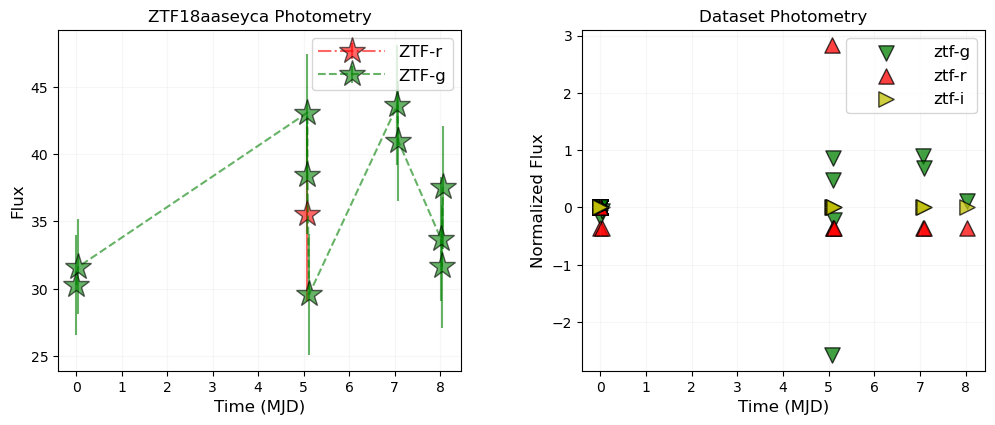

In [77]:
plot_data.compare_tensor_photometry(photometry, obj_id, SEDM_dataset, data_dir)

<a id='dataloader'></a>
<big>part 3: DataLoader</big>
    
    

<i><small>[back to index](#index)</small></i>

In [78]:
train_dataloader = DataLoader(train_dataset, batch_size=128, collate_fn = tune.collate_func,
                              shuffle=True, drop_last=True)
val_dataloader = DataLoader(val_dataset, batch_size=128,collate_fn = tune.collate_func,
                              shuffle=True)

test_dataloader = DataLoader(val_dataset, batch_size=128,collate_fn = tune.collate_func)

In [79]:
batch = next(iter(train_dataloader))
photometry, photometry_mask, _, _, _, target = batch

In [80]:
photometry, photometry_mask, metadata, images, spectra, target  = batch
photometry.shape, photometry_mask.shape, metadata.shape, images.shape, spectra.shape, target.shape,\
photometry.dtype, photometry_mask.dtype, metadata.dtype, images.dtype, spectra.dtype,target.dtype

(torch.Size([128, 225, 4]),
 torch.Size([128, 225]),
 torch.Size([128, 225]),
 torch.Size([128, 225]),
 torch.Size([128, 225]),
 torch.Size([128]),
 torch.float32,
 torch.float32,
 torch.float32,
 torch.float32,
 torch.float32,
 torch.int64)

In [81]:
config = {
    'project': 'AppleCider',
    'mode': 'photo',   
    'config_from': None,    
    'random_seed': 42,
    'use_wandb': True,
    'save_weights': True,
    'weights_path': f'/Users/junell/Documents/AppleCider/AppleCider/weights/photometry/',
    'use_pretrain': None, 'freeze': False, 'num_classes': len(CLASSES),

    # Photometry Model
    'seq_len': 225,
    'p_enc_in': 4,
    'p_d_model': 128,
    'p_dropout': 0.2,
    'p_factor': 1,
    'p_output_attention': False,
    'p_n_heads': 4,
    'p_d_ff': 200,
    'p_activation': 'gelu',
    'p_e_layers': 8,

    # Training
    'batch_size': 350,
    'lr': 0.001,
    'beta1': 0.9,
    'beta2': 0.999,
    'weight_decay': 0.01,
    'epochs': 50,   # when your laptop overheats
    'early_stopping_patience': 100,
    'factor': 0.3,  # for ReduceLROnPlateau scheduler
    'patience': 3,  # for ReduceLROnPlateau scheduler
    'warmup': True,
    'warmup_epochs': 50,
    'clip_grad': False,
    'clip_value': 5
}

In [82]:
#config = run.config

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using', device)

model = Informer(config)
model = model.to(device)

Using cpu


In [83]:
model

Informer(
  (enc_embedding): DataEmbedding(
    (value_embedding): TokenEmbedding(
      (tokenConv): Conv1d(4, 128, kernel_size=(3,), stride=(1,), padding=(1,), bias=False, padding_mode=circular)
    )
    (position_embedding): PositionalEmbedding()
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): Encoder(
    (attn_layers): ModuleList(
      (0): EncoderLayer(
        (attention): AttentionLayer(
          (inner_attention): ProbAttention(
            (dropout): Dropout(p=0.2, inplace=False)
          )
          (query_projection): Linear(in_features=128, out_features=128, bias=True)
          (key_projection): Linear(in_features=128, out_features=128, bias=True)
          (value_projection): Linear(in_features=128, out_features=128, bias=True)
          (out_projection): Linear(in_features=128, out_features=128, bias=True)
        )
        (conv1): Conv1d(128, 200, kernel_size=(1,), stride=(1,))
        (conv2): Conv1d(200, 128, kernel_size=(1,), stride=(1,))
        

In [84]:
with torch.no_grad():
    photometry, photometry_mask = photometry.to(device), photometry_mask.to(device)
    output = model(photometry, photometry_mask)

In [85]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ExponentialLR, ReduceLROnPlateau, LinearLR

optimizer = Adam(model.parameters(), lr=config['lr'], betas=(config['beta1'], config['beta2']),
                 weight_decay=config['weight_decay'])
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=config['factor'], patience=config['patience'])
criterion = torch.nn.CrossEntropyLoss()

In [86]:
wandb.init(
    project=config['project'],
    config=config, group='AB',
    job_type='train')

In [87]:
import torch.nn.functional as F
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix
import os
import optuna

from AppleCider.util.early_stopping import EarlyStopping

class Trainer:
    def __init__(self, model, optimizer, scheduler, warmup_scheduler, criterion, device, config, trial=None):
        
        self.model = model
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.warmup_scheduler = warmup_scheduler
        self.criterion = criterion
        self.device = device
        self.trial = trial

        self.mode = config['mode']
        self.save_weights = config['save_weights']
        self.weights_path = config['weights_path']
        self.use_wandb = config['use_wandb']
        self.early_stopping = EarlyStopping(patience=config['early_stopping_patience'])
        self.warmup_epochs = config['warmup_epochs']
        self.clip_grad = config['clip_grad']
        self.clip_value = config['clip_value']

        self.total_loss = []
        self.total_correct_predictions = 0
        self.total_predictions = 0

    def store_weights(self, epoch):
        torch.save(self.model.state_dict(), os.path.join(self.weights_path, f'weights-{datetime.now().strftime("%Y-%m-%d-%H-%M")}-{epoch}.pth'))
        torch.save(self.model.state_dict(), os.path.join(self.weights_path, f'weights-{datetime.now().strftime("%Y-%m-%d-%H-%M")}-best.pth'))

    def zero_stats(self):
        self.total_loss = []
        self.total_correct_predictions = 0
        self.total_predictions = 0

    # TODO update to 4 elements
    def update_stats_clip(self, loss, logits_ps, logits_sm, logits_mp):
        labels = torch.arange(logits_ps.shape[0], dtype=torch.int64, device=self.device)

        prob_ps = (F.softmax(logits_ps, dim=1) + F.softmax(logits_ps.transpose(-1, -2), dim=1)) / 2
        prob_sm = (F.softmax(logits_sm, dim=1) + F.softmax(logits_sm.transpose(-1, -2), dim=1)) / 2
        prob_mp = (F.softmax(logits_mp, dim=1) + F.softmax(logits_mp.transpose(-1, -2), dim=1)) / 2
        prob = (prob_ps + prob_sm + prob_mp) / 3

        _, pred_labels = torch.max(prob, dim=1)
        correct_predictions = (pred_labels == labels).sum().item()

        self.total_correct_predictions += correct_predictions
        self.total_predictions += labels.size(0)
        self.total_loss.append(loss.item())

    def update_stats(self, loss, logits, labels):
        probabilities = torch.nn.functional.softmax(logits, dim=1)
        _, predicted_labels = torch.max(probabilities, dim=1)
        correct_predictions = (predicted_labels == labels).sum().item()

        self.total_correct_predictions += correct_predictions
        self.total_predictions += labels.size(0)
        self.total_loss.append(loss.item())

    def calculate_stats(self):
        return sum(self.total_loss) / len(self.total_loss), self.total_correct_predictions / self.total_predictions

    def get_logits(self, photometry, photometry_mask, metadata, images, spectra):
        
        if self.mode == 'photo':
            logits = self.model(photometry, photometry_mask)
        elif self.mode == 'spectra':
            logits = self.model(spectra)
        elif self.mode == 'meta':
            logits = self.model(metadata)
        elif self.mode == 'image':
            logits = self.model(images)
        else:  # all 4 modalities
            logits = self.model(photometry, metadata, images, spectra)

        return logits

    # TODO Update to 4 elements
    def step_clip(self, photometry, photometry_mask, spectra, metadata):
        """Perform a training step for the CLIP pretraining model"""
        logits_ps, logits_sm, logits_mp = self.model(photometry, photometry_mask, spectra, metadata)
        
        loss_ps, loss_sm, loss_mp = self.criterion(logits_ps, logits_sm, logits_mp)
        loss = loss_ps + loss_sm + loss_mp

        self.update_stats_clip(loss, logits_ps, logits_sm, logits_mp)

        return loss, loss_ps, loss_sm, loss_mp

    def step(self, photometry, photometry_mask, metadata, images, spectra, labels):
        """Perform a training step for the classification model"""
        logits = self.get_logits(photometry, photometry_mask, metadata, images, spectra)    
        
        loss = self.criterion(logits, labels)

        self.update_stats(loss, logits, labels)

        return loss

    def get_gradient_norm(self):
        total_norm = 0.0

        for param in self.model.parameters():
            if param.grad is not None:
                param_norm = param.grad.data.norm(2)
                total_norm += param_norm.item() ** 2

        return total_norm ** 0.5

    def train_epoch(self, train_dataloader):
        self.model.train()
        self.zero_stats()
        
        for photometry, photometry_mask, metadata, images, spectra, labels in tqdm(train_dataloader):
            photometry, photometry_mask = photometry.to(self.device), photometry_mask.to(self.device)
            metadata, images, spectra = metadata.to(self.device), images.to(self.device), spectra.to(self.device)
            labels = labels.to(self.device)    
            
            self.optimizer.zero_grad()

            if self.mode == 'clip':
                # TODO add images
                loss, loss_ps, loss_sm, loss_mp = self.step_clip(photometry, photometry_mask, spectra, metadata)
                
                if self.use_wandb:
                    wandb.log({'step_loss': loss.item(), 'loss_ps': loss_ps.item(), 'loss_sm': loss_sm.item(),
                               'loss_mp': loss_mp.item()})
            else:
                loss = self.step(photometry, photometry_mask, metadata, images, spectra, labels)

                if self.use_wandb:
                    wandb.log({'step_loss': loss.item()})

            loss.backward()

            if self.use_wandb:
                grad_norm = self.get_gradient_norm()
                wandb.log({'grad_norm': grad_norm})

            if self.clip_grad:
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.clip_value)

                if self.use_wandb:
                    clip_grad_norm = self.get_gradient_norm()
                    wandb.log({'clip_grad_norm': clip_grad_norm})

            self.optimizer.step()

        loss, acc = self.calculate_stats()

        return loss, acc
   

    def val_epoch(self, val_dataloader):
        self.model.eval()
        self.zero_stats()

        with torch.no_grad():
            for photometry, photometry_mask, metadata, images, spectra, labels in tqdm(val_dataloader):
                photometry, photometry_mask = photometry.to(self.device), photometry_mask.to(self.device)
                metadata, images, spectra = metadata.to(self.device), images.to(self.device), spectra.to(self.device)
                labels = labels.to(self.device)

                if self.mode == 'clip':
                    self.step_clip(photometry, photometry_mask, spectra, metadata)
                else:
                    self.step(photometry, photometry_mask, metadata, images, spectra, labels)

        loss, acc = self.calculate_stats()

        return loss, acc
    

    def train(self, train_dataloader, val_dataloader, epochs):
        best_val_loss = np.inf
        best_val_acc = 0

        for epoch in range(epochs):
            train_loss, train_acc = self.train_epoch(train_dataloader)
            val_loss, val_acc = self.val_epoch(val_dataloader)

            best_val_loss = min(val_loss, best_val_loss)

            if self.trial:
                self.trial.report(val_loss, epoch)

                if self.trial.should_prune():
                    print('Prune')
                    wandb.finish()
                    raise optuna.exceptions.TrialPruned()

            if self.warmup_scheduler and epoch < self.warmup_epochs:
                self.warmup_scheduler.step()
                current_lr = self.warmup_scheduler.get_last_lr()[0]
            else:
                self.scheduler.step(val_loss)
                current_lr = self.scheduler.get_last_lr()[0]

            if self.use_wandb:
                wandb.log({'train_loss': train_loss, 'val_loss': val_loss, 'train_acc': train_acc,
                           'val_acc': val_acc,'learning_rate': current_lr, 'epoch': epoch})

            if best_val_acc < val_acc:
                best_val_acc = val_acc

                if self.use_wandb:
                    wandb.log({'best_val_acc': best_val_acc})

                if self.save_weights:
                    self.store_weights(epoch)

            print(f'Epoch {epoch}: Train Loss {round(train_loss, 4)} \t Val Loss {round(val_loss, 4)} \t \
                    Train Acc {round(train_acc, 4)} \t Val Acc {round(val_acc, 4)}')

            if self.early_stopping.step(val_loss):
                print(f'Early stopping at epoch {epoch}')
                break

        return best_val_loss

    def evaluate(self, val_dataloader, id2target):
        self.model.eval()

        all_true_labels = []
        all_predicted_labels = []
        
        
        for photometry, photometry_mask, metadata, images, spectra, labels in tqdm(val_dataloader):
            with torch.no_grad():
                photometry, photometry_mask = photometry.to(self.device), photometry_mask.to(self.device)
                metadata, images, spectra = metadata.to(self.device), images.to(self.device), spectra.to(self.device)

                logits = self.get_logits(photometry, photometry_mask, metadata, images, spectra)
                probabilities = torch.nn.functional.softmax(logits, dim=1)
                _, predicted_labels = torch.max(probabilities, dim=1)

                all_true_labels.extend(labels.numpy())
                all_predicted_labels.extend(predicted_labels.cpu().numpy())

        conf_matrix = confusion_matrix(all_true_labels, all_predicted_labels)
        conf_matrix_percent = 100 * conf_matrix / conf_matrix.sum(axis=1)[:, np.newaxis]

        labels = [id2target[i] for i in range(len(conf_matrix))]
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 7))

        # Plot absolute values confusion matrix
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0])
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('True')
        axes[0].set_title('Confusion Matrix - Absolute Values')

        # Plot percentage values confusion matrix
        sns.heatmap(conf_matrix_percent, annot=True, fmt='.0f', cmap='Blues', xticklabels=labels, yticklabels=labels,
                    ax=axes[1])
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('True')
        axes[1].set_title('Confusion Matrix - Percentages')

        if self.use_wandb:
            wandb.log({'conf_matrix': wandb.Image(fig)})

        return conf_matrix

In [88]:
warmup_scheduler = LinearLR(optimizer, start_factor=1e-5, end_factor=1, total_iters=config['warmup_epochs'])

trainer = Trainer(model=model, optimizer=optimizer, scheduler=scheduler, warmup_scheduler=warmup_scheduler,
                  criterion=criterion, device=device, config=config)

# works until here
trainer.train(train_dataloader, val_dataloader, epochs=config['epochs'])

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

Epoch 0: Train Loss 2.6072 	 Val Loss 2.5669 	                     Train Acc 0.0758 	 Val Acc 0.0519


  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

...

Epoch 24: Train Loss 1.4871 	 Val Loss 1.9758 	                     Train Acc 0.4811 	 Val Acc 0.3474


  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

Epoch 25: Train Loss 1.4856 	 Val Loss 1.9757 	                     Train Acc 0.4803 	 Val Acc 0.3506
Early stopping at epoch 25


1.8890466531117758

  0%|          | 0/15 [00:00<?, ?it/s]

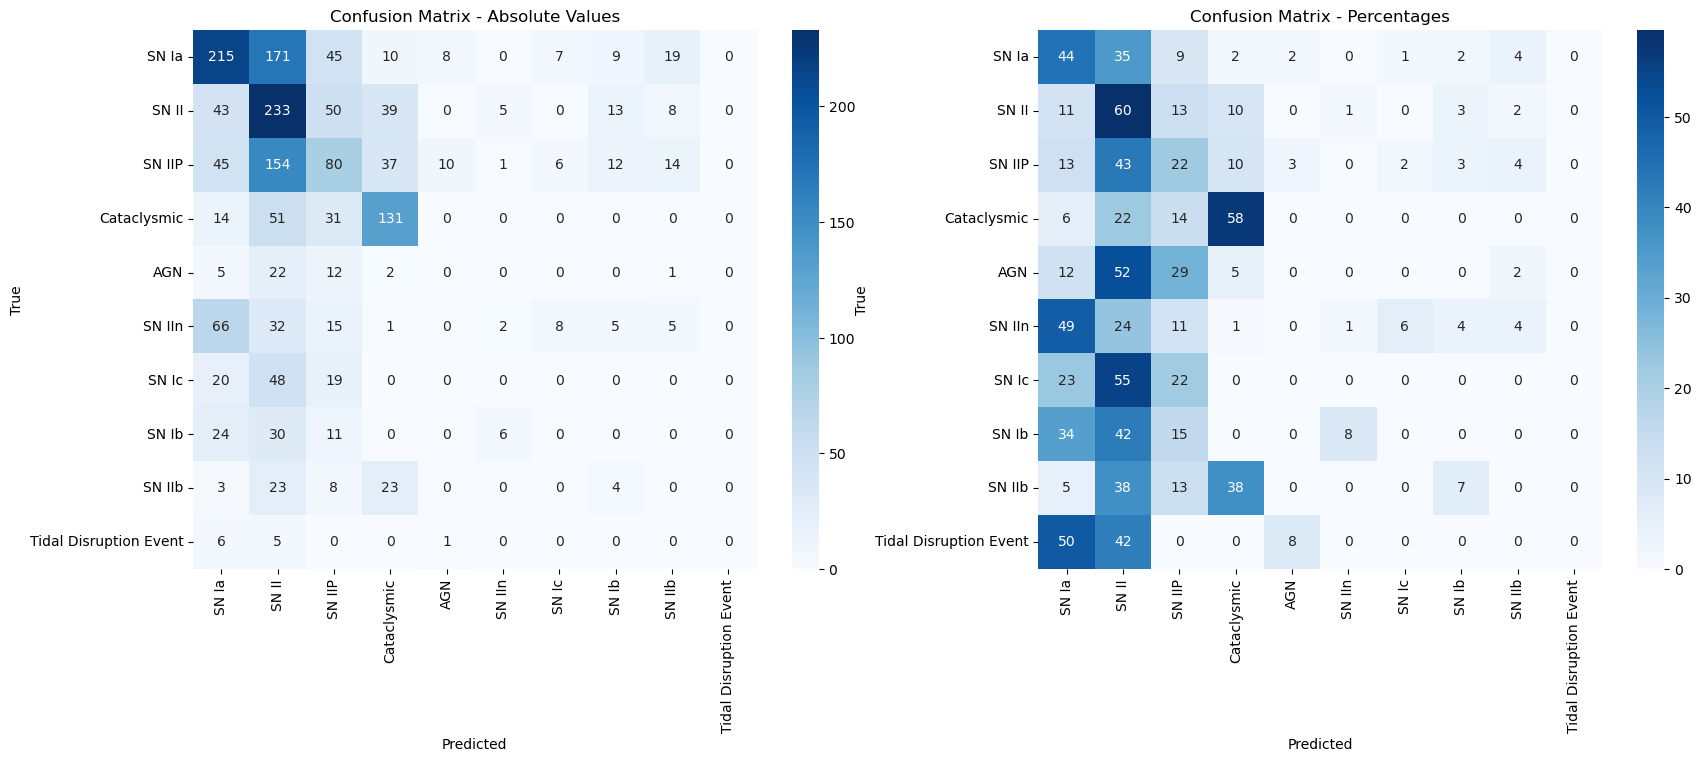

In [89]:
conf_matrix = trainer.evaluate(test_dataloader, id2target={0: 'SN Ia', 1: 'SN II',2: 'SN IIP', 3: 'Cataclysmic', 4: 'AGN',  5: 'SN IIn', 6: 'SN Ic',7: 'SN Ib', 8: 'SN IIb', 9: 'Tidal Disruption Event'})